# ✈️ Airline Customer Segmentation using Unsupervised Machine Learning

**Course:** Unsupervised Machine Learning  
**Dataset:** Airline Frequent Flyer Program — 62,000+ customers  
**Techniques:** K-Means · Agglomerative Hierarchical Clustering · DBSCAN · PCA  
**Framework:** LRFMC (Length, Recency, Frequency, Monetary, Discount Coefficient)

### Feature Description 
#### Identity & Enrollment
* MEMBER_NO : Unique numeric identifier assigned to each Frequent Flyer Program member. This is a database primary key
* FFP_DATE : The date the customer officially enrolled in the Frequent Flyer Program. Used to calculate L (Length) in the LRFMC framework
* LOAD_TIME : The end date of the observation window — the date on which this snapshot of customer data was captured (March 31, 2014 for all records).
#### Demographics
* GENDER : The customer's gender (Male or Female).
* AGE :The customer's age in years at the time of observation.
* WORK_CITY : The city where the customer is based or works.
* WORK_PROVINCE : The province or state of the customer's work location.
* WORK_COUNTRY :The country where the customer is based.
#### Flight Behaviour
* FIRST_FLIGHT_DATE :The date the customer took their very first flight with this airline.
* LAST_FLIGHT_DATE : The date of the customer's most recent recorded flight before the observation window closed.
* FLIGHT_COUNT :The total number of flights the customer has taken throughout their entire membership history.
* LAST_TO_END :The number of days between the customer's last flight and the end of the observation window (March 31, 2014).
* AVG_INTERVAL :The average number of days between consecutive flights for this customer across their entire history.
* MAX_INTERVAL : The longest gap in days between any two consecutive flights in the customer's history.
* SEG_KM_SUM :The total distance in kilometers flown by the customer across all flights in their history. This is the source of M (Monetary) in the LRFMC framework. 
#### Revenue & Loyality Points
* SUM_YR_1 : Total fare revenue (in currency units) generated by the customer during the first year of the observation window. 
* SUM_YR_2 : Total fare revenue generated during the second year of the observation window. 63 missing values filled with 0.
* BP_SUM : Total bonus points accumulated by the customer through flight activity across their entire membership history. Bonus points are awarded based on distance flown, fare class, and loyalty tier.
* Points_Sum : The total loyalty points currently held in the customer's account — including flight bonus points, partner points, and any points earned through non-flight activities.
* Point_NotFlight : Points earned through non-flight activities — hotel stays, car rentals, credit card purchases, retail partner transactions, and other loyalty program ecosystem activities.
* EXCHANGE_COUNT : The number of times the customer has redeemed or exchanged their loyalty points for rewards
* avg_discount : The average discount coefficient applied across all tickets purchased by the customer. A value of 1.0 means the customer consistently pays full fare. Values below 1.0 indicate discounted tickets — the lower the value, the more deeply discounted.
* FFP_TIER : Tier of Frequent Flyer Program

---
## 1. Introduction

### Business Context

Airlines operate one of the most data-rich loyalty programs in any industry.  
The **Frequent Flyer Program (FFP)** of this Chinese airline has enrolled 62,000+ members,  
each generating rich behavioral data — flights taken, distances flown, points earned, and more.

### The Problem

Despite this data richness, airlines often market to every member **identically** — 
the same email, the same offer, the same tier communication.  
This is wasteful and ineffective. A business traveler flying 200 times a year  
and an occasional holiday flyer have nothing in common strategically.

### Our Goal

Apply **unsupervised machine learning** — without any pre-existing labels — to:
1. Discover natural behavioral segments hidden in the data
2. Profile each segment using the LRFMC framework
3. Assign meaningful business labels to each cluster
4. Recommend tailored strategies per segment

### Why LRFMC?

The standard RFM (Recency, Frequency, Monetary) model is adapted for aviation as LRFMC:

| Dimension | Meaning | Airline Relevance |
|---|---|---|
| **L** — Length | Membership duration | Long-term loyal vs new member |
| **R** — Recency | Days since last flight | Active vs lapsing |
| **F** — Frequency | Total flights | Business vs leisure traveler |
| **M** — Monetary | Total km flown | Route value, seat class proxy |
| **C** — Discount | Avg discount coefficient | Price sensitivity, fare type |

### Algorithms Used

- **K-Means** — Primary clustering; interpretable centroids; scalable to 62K rows
- **Agglomerative Hierarchical** — Validates cluster count via dendrogram; no K assumption
- **DBSCAN** — Identifies outlier customers and irregular density clusters
- **PCA** — Reduces 5 LRFMC dimensions to 2D for visual cluster comparison


---
## 2. Dataset Overview

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_rows', None)

# Set the visual style
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully.")
print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")

Libraries loaded successfully.
pandas  : 2.3.3
numpy   : 2.3.5


### Load Data

In [2]:
import sys, os
sys.path.append(os.path.abspath('..'))

train = pd.read_csv("..\\data\\raw\\flight_train.csv")
test = pd.read_csv("..\\data\\raw\\flight_test.csv")

print(train.shape)
print(test.shape)

(55000, 23)
(7988, 23)


In [3]:
train = pd.concat([train,test])

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 62988 entries, 0 to 7987
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MEMBER_NO          62988 non-null  int64  
 1   FFP_DATE           62988 non-null  object 
 2   FIRST_FLIGHT_DATE  62988 non-null  object 
 3   GENDER             62985 non-null  object 
 4   FFP_TIER           62988 non-null  int64  
 5   WORK_CITY          60719 non-null  object 
 6   WORK_PROVINCE      59740 non-null  object 
 7   WORK_COUNTRY       62962 non-null  object 
 8   AGE                62568 non-null  float64
 9   LOAD_TIME          62988 non-null  object 
 10  FLIGHT_COUNT       62988 non-null  int64  
 11  BP_SUM             62988 non-null  int64  
 12  SUM_YR_1           62437 non-null  float64
 13  SUM_YR_2           62850 non-null  float64
 14  SEG_KM_SUM         62988 non-null  int64  
 15  LAST_FLIGHT_DATE   62988 non-null  object 
 16  LAST_TO_END        62988 non

In [5]:
# Sample records
train.head(5)

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME,...,SUM_YR_2,SEG_KM_SUM,LAST_FLIGHT_DATE,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight
0,54993,11/2/2006,12/24/2008,Male,6,.,beijing,CN,31.0,3/31/2014,...,234188.0,580717,3/31/2014,1,3.483254,18,34,0.961639,619760,50
1,28065,2/19/2007,8/3/2007,Male,6,NaN,beijing,CN,42.0,3/31/2014,...,167434.0,293678,3/25/2014,7,5.194245,17,29,1.252314,415768,33
2,55106,2/1/2007,8/30/2007,Male,6,.,beijing,CN,40.0,3/31/2014,...,164982.0,283712,3/21/2014,11,5.298507,18,20,1.254676,406361,26
3,21189,8/22/2008,8/23/2008,Male,5,Los Angeles,CA,US,64.0,3/31/2014,...,125500.0,281336,12/26/2013,97,27.863636,73,11,1.090870,372204,12
4,39546,4/10/2009,4/15/2009,Male,6,guiyang,guizhou,CN,48.0,3/31/2014,...,130702.0,309928,3/27/2014,5,4.788079,47,27,0.970658,338813,39


In [6]:
# Statistical summary of numeric columns
train.describe().round(2)

,MEMBER_NO,FFP_TIER,AGE,FLIGHT_COUNT,BP_SUM,SUM_YR_1,SUM_YR_2,SEG_KM_SUM,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight
count,62988.00,62988.00,62568.00,62988.00,62988.00,62437.00,62850.00,62988.00,62988.00,62988.00,62988.00,62988.00,62988.00,62988.00,62988.00
mean,31494.50,4.10,42.48,11.84,10925.08,5355.38,5604.03,17123.88,176.12,67.75,166.03,0.32,0.72,12545.78,2.73
std,18183.21,0.37,9.89,14.05,16339.49,8109.45,8703.36,20960.84,183.82,77.52,123.40,1.14,0.19,20507.82,7.36
min,1.00,4.00,6.00,2.00,0.00,0.00,0.00,368.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,15747.75,4.00,35.00,3.00,2518.00,1003.00,780.00,4747.00,29.00,23.37,79.00,0.00,0.61,2775.00,0.00
50%,31494.50,4.00,41.00,7.00,5700.00,2800.00,2773.00,9994.00,108.00,44.67,143.00,0.00,0.71,6328.50,0.00
75%,47241.25,4.00,48.00,15.00,12831.00,6574.00,6845.75,21271.25,268.00,82.00,228.00,0.00,0.81,14302.50,1.00
max,62988.00,6.00,110.00,213.00,505308.00,239560.00,234188.00,580717.00,731.00,728.00,728.00,46.00,1.50,985572.00,140.00


In [7]:
train.shape

(62988, 23)

### Dataset Summary

The raw dataset contains **62,988 customer records** and **23 columns** covering:
- **Identity** fields: `MEMBER_NO`, enrollment/flight dates
- **Demographic** fields: `GENDER`, `AGE`, work location
- **Behavioral** fields: flight counts, distances, revenue, intervals, points, discounts
- **Loyalty** fields: FFP tier, exchange counts, bonus points

The observation snapshot date is **March 31, 2014** (stored as `LOAD_TIME`).  
This dataset comes from a **Chinese airline** — the majority of customers have `WORK_COUNTRY = CN`.

> **Key insight at this stage:** The dataset has no target variable. Our task is entirely unsupervised —  
> we must discover structure purely from the behavioral patterns present in the data.


---
## 3. Exploratory Data Analysis (EDA)

EDA is the foundation of every ML project. Before touching any algorithm, we must  
understand what the data contains, what it's missing, and what patterns already  
exist at a surface level.


### 3.1 missing values

In [8]:
missing_df = pd.DataFrame({
    'missing_count': train.isnull().sum(),
    'missing_percent': (train.isnull().sum() / len(train)) * 100
})

# Show only columns that have missing values
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_percent', ascending=False)

print("Columns with missing values:")
print(missing_df.to_string())

Columns with missing values:
               missing_count  missing_percent
WORK_PROVINCE           3248         5.156538
WORK_CITY               2269         3.602273
SUM_YR_1                 551         0.874770
AGE                      420         0.666794
SUM_YR_2                 138         0.219089
WORK_COUNTRY              26         0.041278
GENDER                     3         0.004763


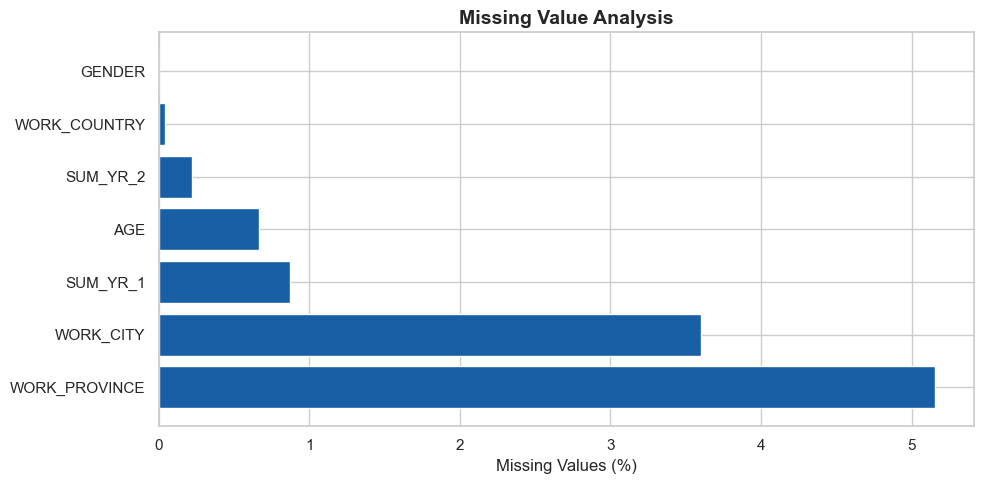

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.barh(missing_df.index, missing_df['missing_percent'], color='#185FA5', edgecolor='white')

plt.xlabel('Missing Values (%)')
plt.title('Missing Value Analysis', fontsize=14, fontweight='bold')
# plt.axvline(x=5, color='red', linestyle='--', alpha=0.5, label='5% threshold')
# plt.legend()
plt.tight_layout()
plt.show()

**Missing value observations:**
- `WORK_PROVINCE` (~5.1%) & `WORK_CITY` (~3.6%): High cardinality location fields — will be **dropped** regardless
- `AGE` (0.62%): Small enough to impute with **median** (robust to skew)
- `SUM_YR_1` (0.48%), `SUM_YR_2` (0.11%): Customers with no activity in that year → **fill with 0**
- `GENDER` (0.005%): Near-negligible → **fill with mode**

None of the behavioral features used in LRFMC have any missing values.


### 3.2 Duplicate Records

In [10]:
dups = train.duplicated().sum()
print(f"Duplicate rows: {dups}")
print("→ No duplicate records found." if dups == 0 else f"→ {dups} duplicates need removal.")

Duplicate rows: 0
→ No duplicate records found.


### 3.3 Univariate Distributions — Numeric Features

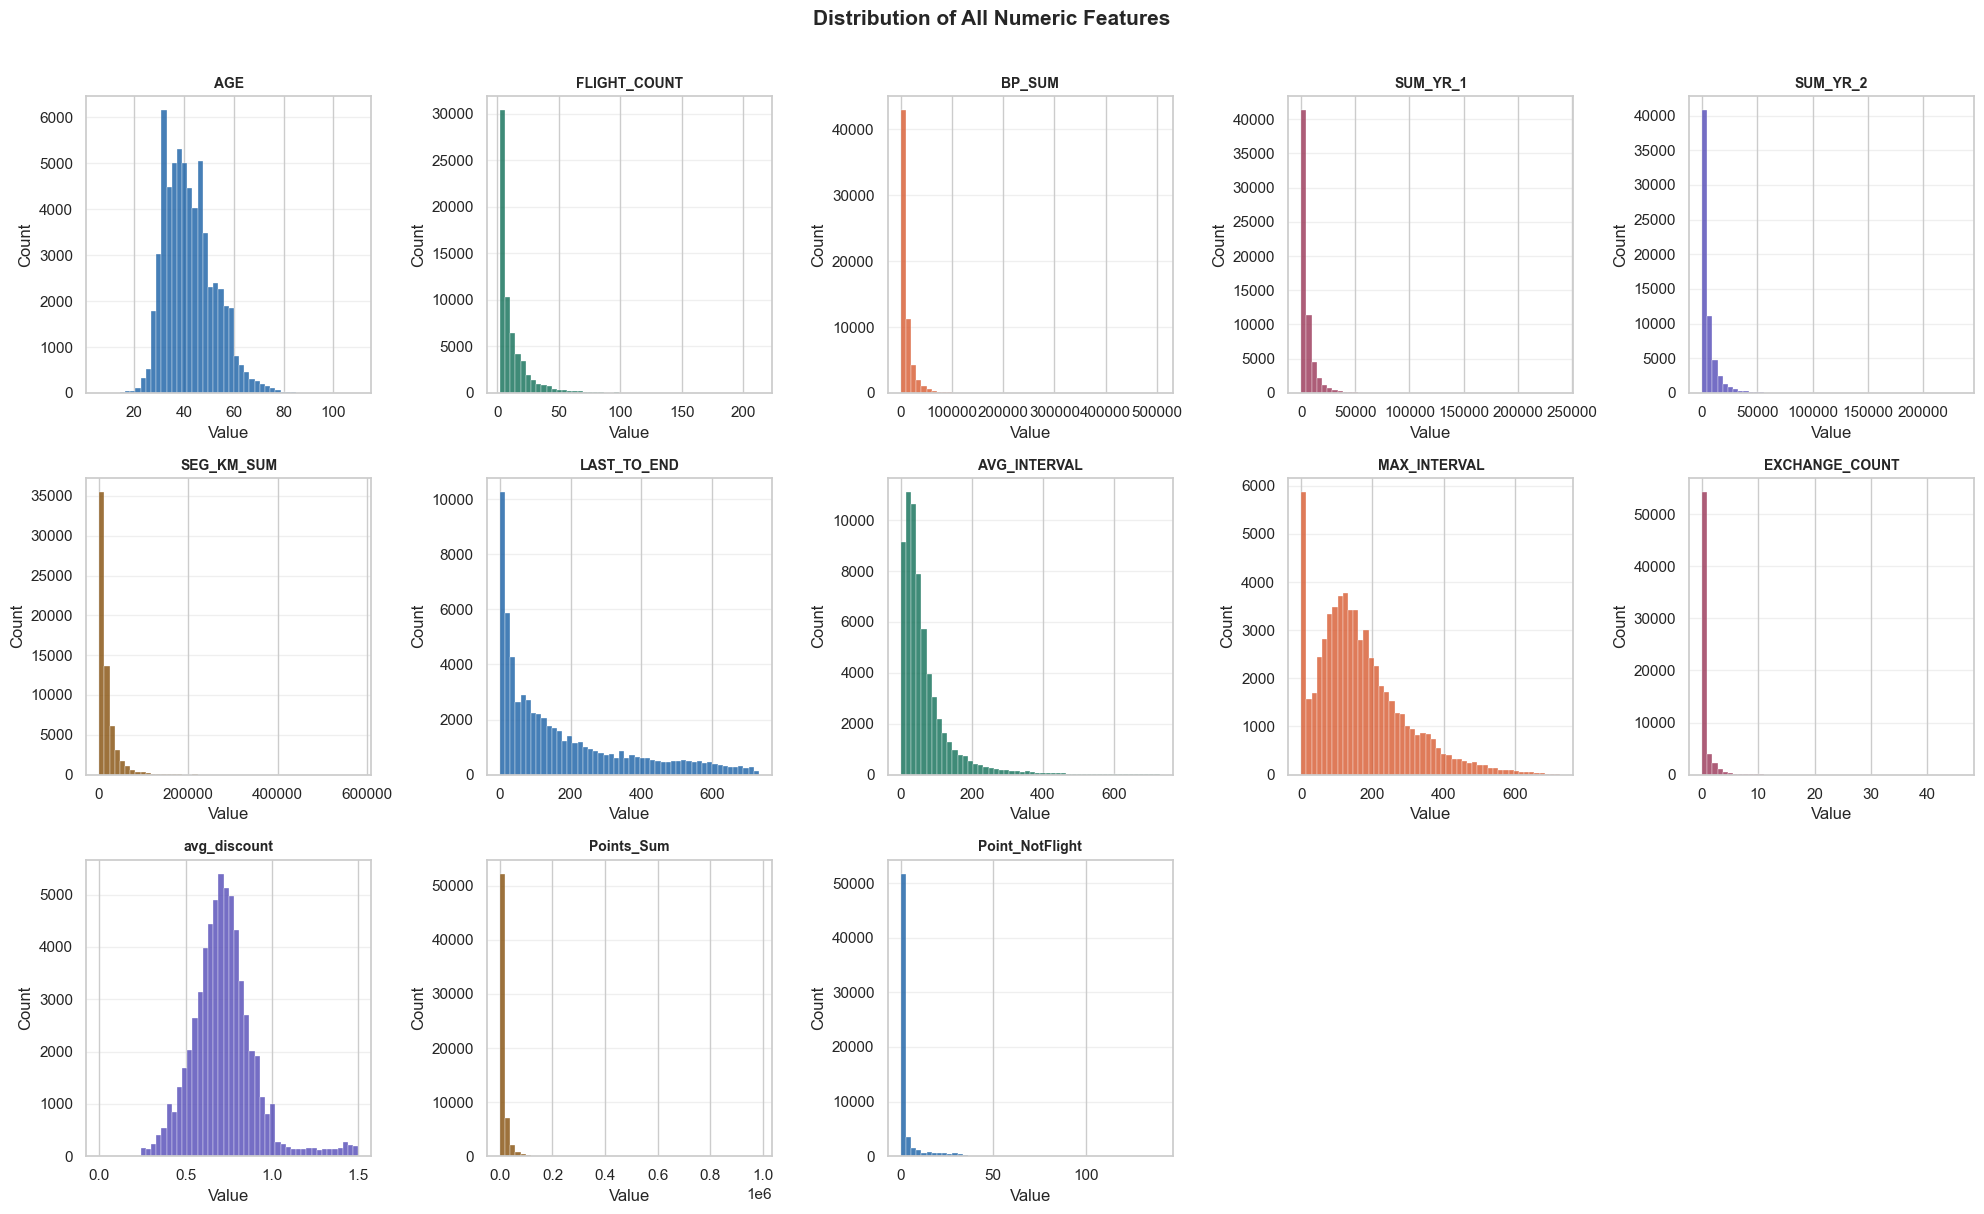

In [11]:
# These are all the numeric columns we want to understand
numeric_cols = [
    'AGE', 'FLIGHT_COUNT', 'BP_SUM', 'SUM_YR_1', 'SUM_YR_2',
    'SEG_KM_SUM', 'LAST_TO_END', 'AVG_INTERVAL', 'MAX_INTERVAL',
    'EXCHANGE_COUNT', 'avg_discount', 'Points_Sum', 'Point_NotFlight'
]

# Create a grid of plots — 3 rows, 5 columns
fig, axes = plt.subplots(3,5, figsize=(20, 12))

# Flatten the grid into a simple list so we can loop through it
axes = axes.flatten()

# One color per plot to make it visually easy to read
colors = ['#185FA5', '#0F6E56', '#D85A30', '#993556', '#534AB7',
          '#854F0B', '#185FA5', '#0F6E56', '#D85A30', '#993556',
          '#534AB7', '#854F0B', '#185FA5']

for i, (col, color) in enumerate(zip(numeric_cols, colors)):
    axes[i].hist(train[col].dropna(), bins=50, color=color, 
                 alpha=0.8, edgecolor='white', linewidth=0.3)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].grid(axis='y', alpha=0.3)

# Hide the 2 empty subplots (we have 13 cols, grid has 15 spots)
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribution of All Numeric Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Distribution observations:**

- `FLIGHT_COUNT`, `SEG_KM_SUM`, `BP_SUM`, `Points_Sum`: Strongly **right-skewed** — a small group of customers flies far more than the majority. These are our likely VIP customers.
- `AGE`: Roughly **bell-shaped**, centered around 35–45. Classic business traveler demographic.
- `LAST_TO_END`: Most customers flew **recently** (low values), but a tail of customers haven't flown in 200–700 days — potential at-risk segment.
- `AVG_INTERVAL`: Most fly every 10–30 days, but some have very long gaps (infrequent flyers).
- `avg_discount`: Peaks around 0.6–0.8 with most customers receiving some discount. Full-fare payers (~1.0) are a minority.
- `EXCHANGE_COUNT` and `Point_NotFlight`: Extremely skewed — most customers never exchange points or earn non-flight points.


In [12]:
import pandas as pd
import numpy as np

numeric_cols = [
    'AGE', 'FLIGHT_COUNT', 'BP_SUM', 'SUM_YR_1', 'SUM_YR_2',
    'SEG_KM_SUM', 'LAST_TO_END', 'AVG_INTERVAL', 'MAX_INTERVAL',
    'EXCHANGE_COUNT', 'avg_discount', 'Points_Sum', 'Point_NotFlight'
]

# Calculate skewness for each column
skew_df = pd.DataFrame({
    'Skewness': train[numeric_cols].skew().round(2)
}).sort_values('Skewness', ascending=False)

# Label each one so it's easy to interpret
def skew_label(s):
    if s > 2:
        return 'Highly Right Skewed'
    elif s > 1:
        return 'Moderately Right Skewed'
    elif s > 0.5:
        return 'Slightly Right Skewed'
    elif s < -1:
        return 'Left Skewed'
    else:
        return 'Roughly Symmetric'

skew_df['Interpretation'] = skew_df['Skewness'].apply(skew_label)

print(skew_df.to_string())

                 Skewness           Interpretation
Points_Sum           8.38      Highly Right Skewed
EXCHANGE_COUNT       8.20      Highly Right Skewed
BP_SUM               5.66      Highly Right Skewed
SUM_YR_1             5.09      Highly Right Skewed
SUM_YR_2             4.60      Highly Right Skewed
Point_NotFlight      4.27      Highly Right Skewed
SEG_KM_SUM           3.88      Highly Right Skewed
FLIGHT_COUNT         3.22      Highly Right Skewed
AVG_INTERVAL         3.21      Highly Right Skewed
LAST_TO_END          1.18  Moderately Right Skewed
MAX_INTERVAL         1.07  Moderately Right Skewed
avg_discount         0.96    Slightly Right Skewed
AGE                  0.63    Slightly Right Skewed


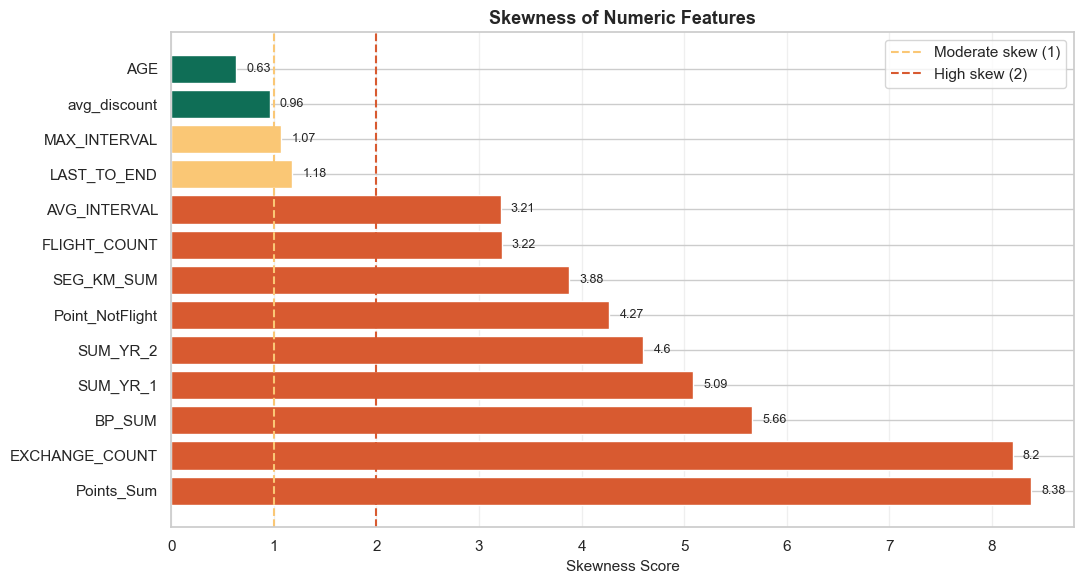

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 6))

# Color bars by severity
bar_colors = []
for s in skew_df['Skewness']:
    if s > 2:
        bar_colors.append('#D85A30')    # red = high skew
    elif s > 1:
        bar_colors.append('#FAC775')    # amber = moderate
    else:
        bar_colors.append('#0F6E56')    # green = fine

bars = ax.barh(skew_df.index, skew_df['Skewness'],
               color=bar_colors, edgecolor='white')

# Reference lines
ax.axvline(x=1, color='#FAC775', linestyle='--',
           linewidth=1.5, label='Moderate skew (1)')
ax.axvline(x=2, color='#D85A30', linestyle='--',
           linewidth=1.5, label='High skew (2)')

# Value labels on bars
for bar, val in zip(bars, skew_df['Skewness']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

ax.set_xlabel('Skewness Score', fontsize=11)
ax.set_title('Skewness of Numeric Features', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 3.4 Outlier Detection

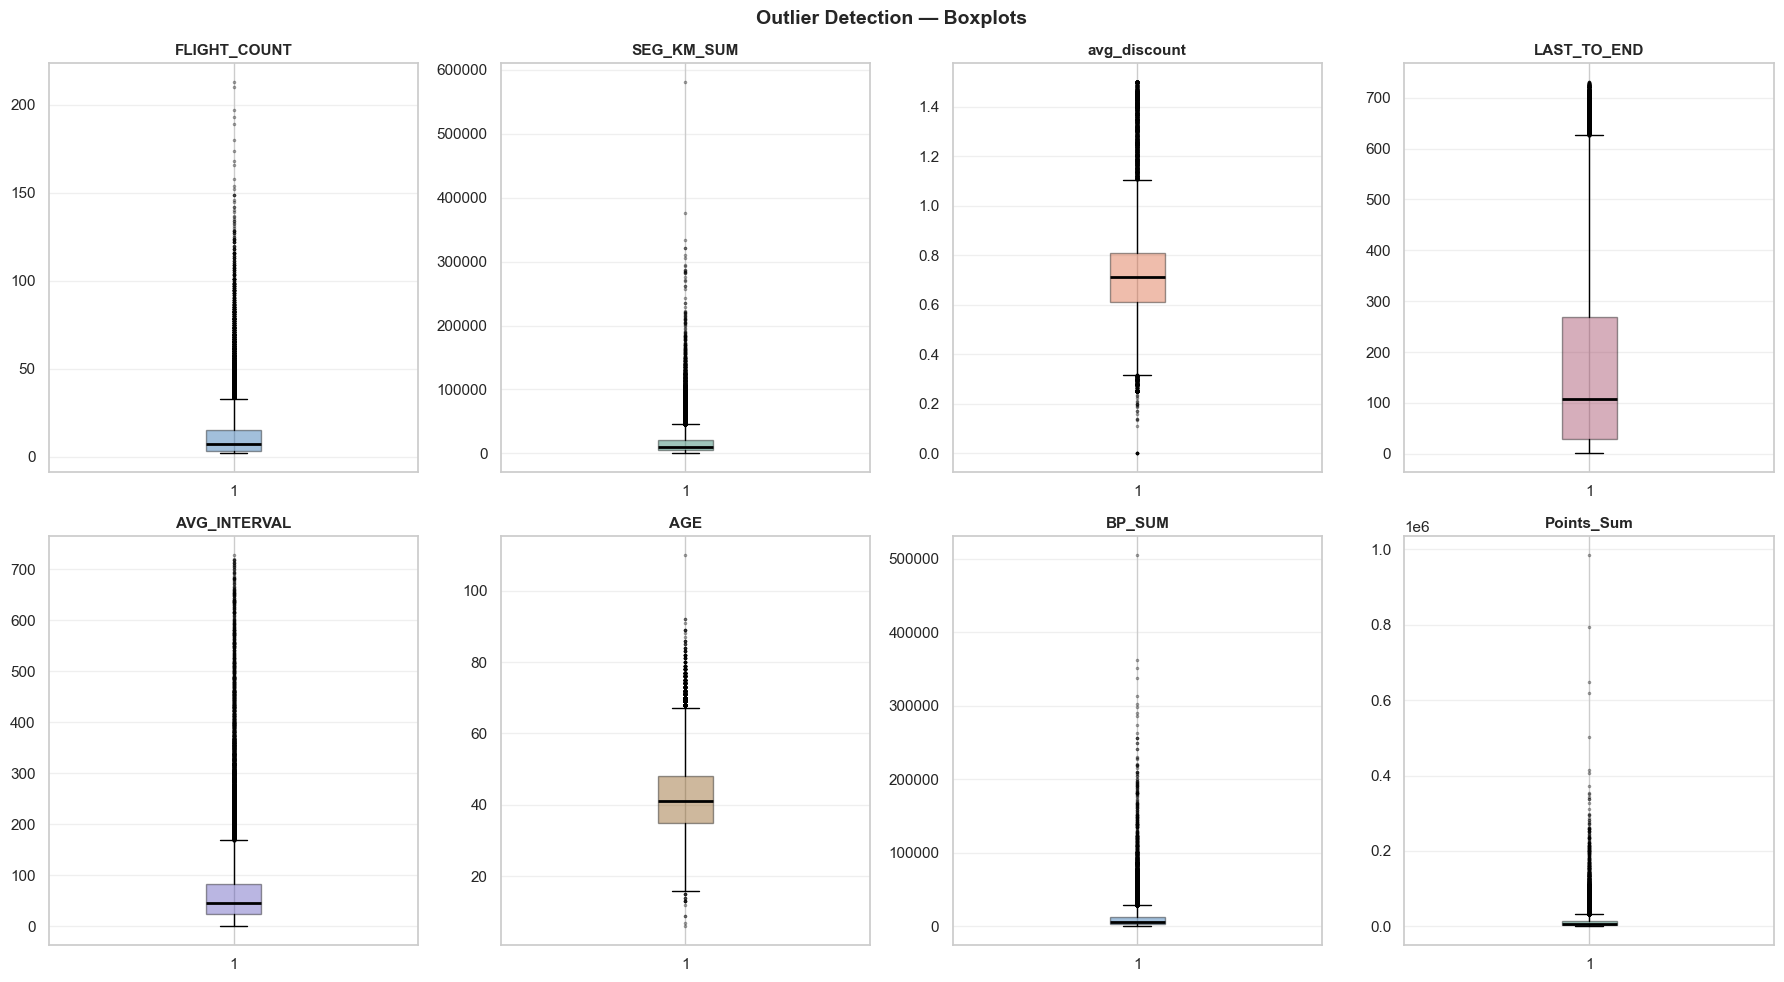

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

outlier_cols = [
    'FLIGHT_COUNT', 'SEG_KM_SUM', 'avg_discount',
    'LAST_TO_END', 'AVG_INTERVAL', 'AGE', 'BP_SUM', 'Points_Sum'
]

colors = ['#185FA5','#0F6E56','#D85A30','#993556',
          '#534AB7','#854F0B','#185FA5','#0F6E56']

for ax, col, color in zip(axes, outlier_cols, colors):
    ax.boxplot(train[col].dropna(),
               patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.4),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='.', markersize=3, alpha=0.4, color=color))
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Outlier Detection — Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
print("Outlier counts using IQR method")
print("-" * 42)

for col in outlier_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = ((train[col] < lower) | (train[col] > upper)).sum()
    pct = outlier_count / len(train) * 100
    print(f"{col:<20}: {outlier_count:>5} outliers ({pct:.1f}%)")

Outlier counts using IQR method
------------------------------------------
FLIGHT_COUNT        :  4304 outliers (6.8%)
SEG_KM_SUM          :  4792 outliers (7.6%)
avg_discount        :  2573 outliers (4.1%)
LAST_TO_END         :  1835 outliers (2.9%)
AVG_INTERVAL        :  4840 outliers (7.7%)
AGE                 :   998 outliers (1.6%)
BP_SUM              :  5315 outliers (8.4%)
Points_Sum          :  5516 outliers (8.8%)


* `FLIGHT_COUNT`,`SEG_KM_SUM` and `BP_SUM` showing many outliers on the high end but these are not errors they are the real VIP customers.
* `avg_discount` also showing a few extreme values those we can recap

## 3.5 Correlation Analysis

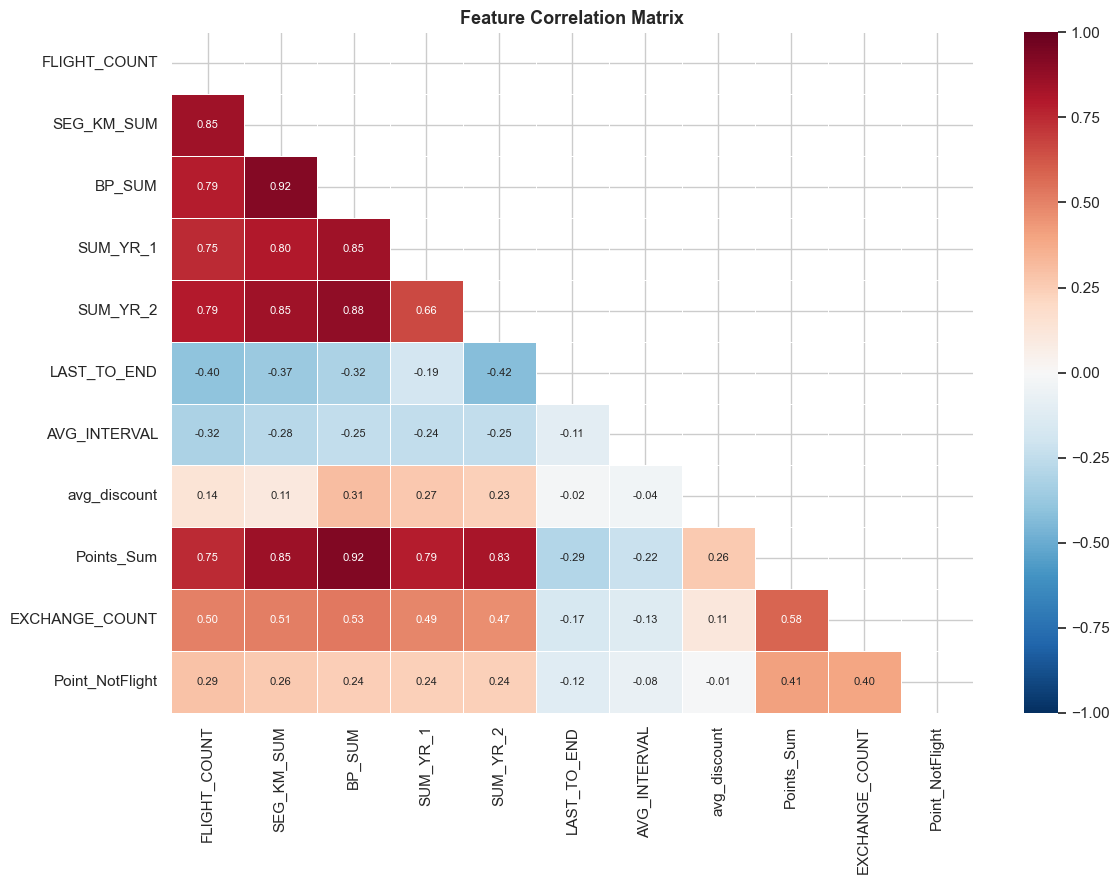

In [16]:
import seaborn as sns
import numpy as np

corr_cols = [
    'FLIGHT_COUNT', 'SEG_KM_SUM', 'BP_SUM',
    'SUM_YR_1', 'SUM_YR_2', 'LAST_TO_END',
    'AVG_INTERVAL', 'avg_discount', 'Points_Sum',
    'EXCHANGE_COUNT', 'Point_NotFlight'
]

corr_matrix = train[corr_cols].corr()

# Only show lower triangle — removes the mirror duplicates
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, mask=mask,
            annot=True, fmt='.2f',
            cmap='RdBu_r', center=0,
            vmin=-1, vmax=1,
            linewidths=0.5,
            annot_kws={'size': 8},
            ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

* `BP_SUM` and `Points_Sum` are nearly identical **(0.92)**
These two columns are telling you almost the same story. Keeping both in clustering would give that information double weight. We only need one. We'll keep `SEG_KM_SUM` as our monetary measure and drop both.
* `FLIGHT_COUNT` and `SEG_KM_SUM` are highly correlated **(0.85)**
Makes sense — the more you fly, the more km you rack up. In our LRFMC model, `FLIGHT_COUNT` becomes **F** and `SEG_KM_SUM` becomes **M**. Even though they're correlated, they capture different things — volume vs distance — so we keep both but it's good to know.
* `SUM_YR_1` and `SUM_YR_2` correlate strongly with `BP_SUM` **(0.85, 0.88)**
Revenue columns are basically captured by the points columns. We don't need revenue as a separate feature.
* `LAST_TO_END` is negatively correlated with everything **(-0.40, -0.37...)**
This makes perfect sense. Customers who flew recently (low `LAST_TO_END`) tend to fly more often, accumulate more points, fly more km. Recency is connected to everything — it's a strong signal.
* `avg_discount` is barely correlated with anything **(0.14, 0.11...)**
This means discount behavior is independent of flying behavior. A heavy flyer might still take discounts. This makes `avg_discount` a very unique feature — it adds information that none of the other columns already capture.

## EDA Summary

* There is no duplicate rows
* 7 columns have missing values, none critical to LRFMC
* 10 out of 13 numerical features are right skewed
* VIP outliers exist in `FLIGHT_COUNT`, `SEG_KM_SUM`, `BP_SUM`
* `BP_SUM` and `points_sum` are redundant **(r=0.92)**
* `avg_discount` is independent - unique signal
* `LAST_TO_END` negatively correlates with activity 

---

## 4. Data Preprocessing and Feature Engineering

* $Data  Preprocessing$ - Based on the EDA findings, we now clean the dataset systematically. Every decision is justified by what we observed in section 3.

* $Feature  Engineering$ - This is the most critical analytical step. Rather than clustering on 15+ raw columns(many of which are correlated or redundant), we engineer exactly **5 clean LRFMC dimensions** that capture the filll behavioural picture with minimal redundancy.

In [17]:
import sys
sys.path.append("C:\\Users\\anura\\Desktop\\fly") 

from src.preprocessing import preprocess
from src.feature_engineering import engineer_features, scale_features

# Run preprocessing
df_clean = preprocess(train.copy())

# Run feature engineering
df_lrfmc = engineer_features(df_clean.copy())

Duplicates removed: 0
Invalid records removed: 52
Preprocessing complete. Shape: (62936, 18)
Feature engineering complete. Shape: (62936, 5)
Columns: ['L', 'R', 'F', 'M', 'C']


* 52 rows removed those were customers with impossible ages or zero activity across all columns. 62,936 clean customers remain with 18 columns
* From 18 columns down to exactly 5 clean **LRFMC** features. This is the matrix that goes into clustering

### 5.1 Scaling

In [18]:
# Scale for clustering
X_scaled, scaler = scale_features(df_lrfmc)

print(X_scaled.head())
print(X_scaled.describe().round(3))

          L         R         F         M         C
0  1.253487 -2.537114  3.820317  3.963264  1.294850
1  1.187393 -1.591471  3.336908  3.294649  2.862764
2  1.198496 -1.314888  3.293610  3.260791  2.875500
3  0.804842  0.117643  1.213418  3.252544  1.991925
4  0.612380 -1.787710  3.434859  3.347465  1.343498
               L          R          F          M          C
count  62936.000  62936.000  62936.000  62936.000  62936.000
mean       0.000      0.000      0.000     -0.000      0.000
std        1.000      1.000      1.000      1.000      1.000
min       -1.964     -2.537     -1.280     -3.256     -3.892
25%       -0.845     -0.690     -0.935     -0.750     -0.591
50%        0.039      0.184     -0.104     -0.020     -0.052
75%        0.905      0.804      0.727      0.720      0.474
max        1.638      1.489      3.837      3.963      4.199


* After standard scaler every column has mean=0 and std=1. This means all features are now on the same scale. K-means will treat L,R,F,M and C equally when calculating distances. No single column dominates anymore 

In [19]:
import numpy as np
from src.clustering import (apply_pca, compute_elbow, plot_elbow,
                             plot_silhouette_scores, run_kmeans,
                            run_hierarchical,
                             run_dbscan, plot_clusters_pca)
from src.evaluation import (compare_all_algorithms, plot_cluster_profiles)

### 5.2 PCA — Dimensionality Reduction

In [20]:
# PCA for visualisation
X_pca, pca = apply_pca(X_scaled.values)

PC1: 48.5%  |  PC2: 20.4%  |  Total: 68.9% variance kept


### PCA Interpretation

PC1 and PC2 together capture ~69% of the variance in the LRFMC space.  
The loadings tell us what each principal component actually represents:

- **PC1** is primarily driven by F (frequency) and M (monetary/km) — it represents **customer activity level**. High PC1 = heavy flyer.
- **PC2** is primarily driven by R (recency) and C (discount) — it represents **engagement quality**. High PC2 = recently active, lower discount sensitivity.

> We use PCA only for **visualization** — all clustering is performed on the full 5D scaled LRFMC space, not the 2D PCA projection.

---

## 6. Clustering Experiements

We apply all three algorithms in sequence.\
Each has different assumptions, strengths, and failure modes.\
Running all three and comparing results gives us confidence in our final segmantation.

### 6.1 K-Means — Finding Optimal K

  K=2  Inertia: 209,529
  K=3  Inertia: 179,702
  K=4  Inertia: 159,533
  K=5  Inertia: 141,918
  K=6  Inertia: 129,915
  K=7  Inertia: 119,018
  K=8  Inertia: 110,646
  K=9  Inertia: 103,937
  K=10  Inertia: 97,931


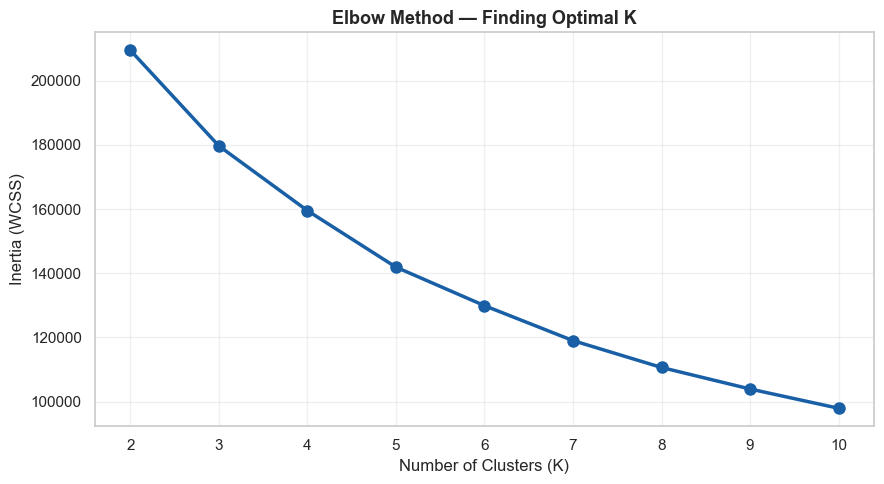

In [21]:
# Elbow method
wcss = compute_elbow(X_scaled.values)
plot_elbow(wcss)

  K=2  Silhouette Score: 0.2913
  K=3  Silhouette Score: 0.2285
  K=4  Silhouette Score: 0.2045
  K=5  Silhouette Score: 0.2051
  K=6  Silhouette Score: 0.1922
  K=7  Silhouette Score: 0.1986
  K=8  Silhouette Score: 0.2053
  K=9  Silhouette Score: 0.2019
  K=10  Silhouette Score: 0.1990


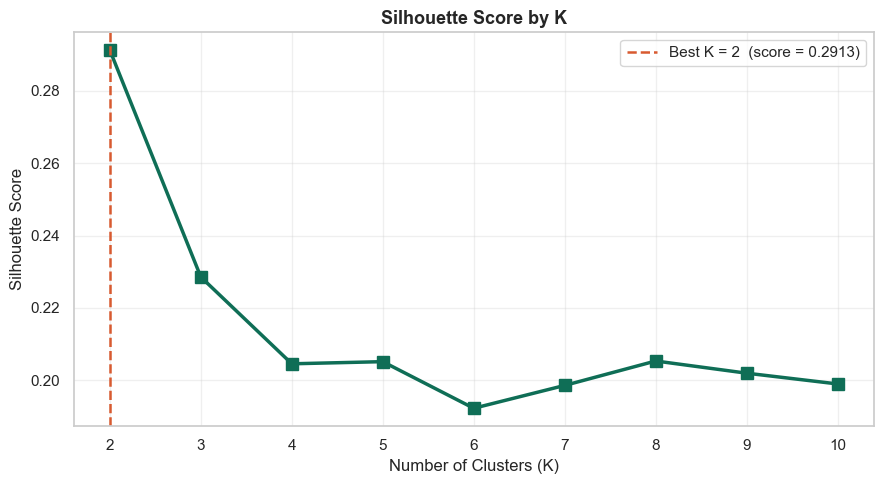


  Best K by silhouette: 2
Best K: 2


In [22]:
# Silhouette scores
scores, best_k = plot_silhouette_scores(X_scaled.values)
print(f"Best K: {best_k}")

* From this we can see 2 is best
* 2 only divide into 2 group its not much helpful
* Better option is 4 so choose K=4

### 6.2 K-Means — Final Model

In [23]:
# ── K-Means on full data ──
km_model, km_labels = run_kmeans(X_scaled.values, n_clusters=4)
print(f"K-Means cluster sizes:")
import pandas as pd
print(pd.Series(km_labels).value_counts().sort_index())

K-Means fitted with K=4
K-Means cluster sizes:
0    14657
1    15514
2    14205
3    18560
Name: count, dtype: int64


### 6.3 Agglomerative Hierarchical Clustering

In [24]:
# ── Hierarchical on sample ──
agg_model, agg_sample_labels, agg_idx = run_hierarchical(
    X_scaled.values, n_clusters=4, sample_size=10000
)
print(f"Hierarchical cluster sizes (sample):")
print(pd.Series(agg_sample_labels).value_counts().sort_index())

Hierarchical Clustering fitted on 10,000 sample rows
K=4, linkage='ward'
Hierarchical cluster sizes (sample):
0    3835
1    3179
2    2628
3     358
Name: count, dtype: int64


### 6.4 DBSCAN — Density-Based Clustering


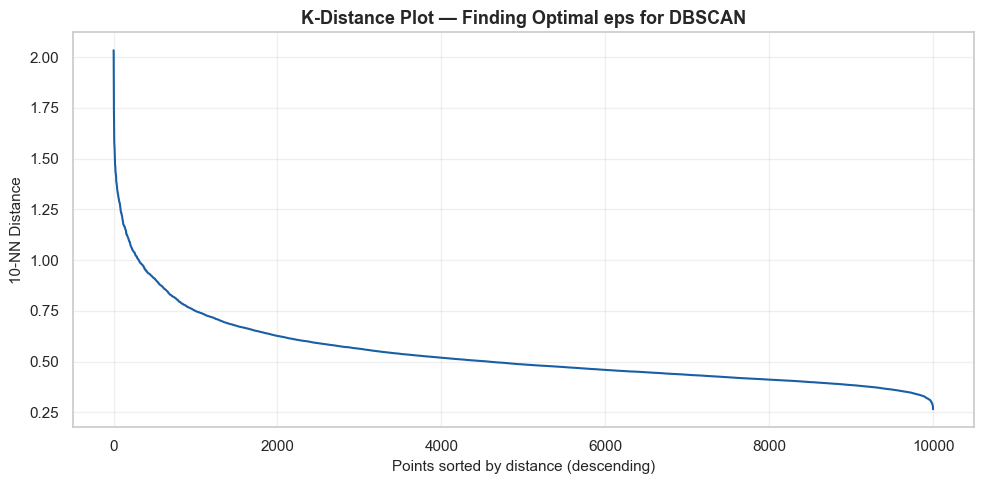

In [25]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Use same k as min_samples
k = 10

# Sample for speed
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=10000, replace=False)
X_sample = X_scaled.values[sample_idx]

# Find distance to kth nearest neighbour for each point
nbrs = NearestNeighbors(n_neighbors=k).fit(X_sample)
distances, _ = nbrs.kneighbors(X_sample)

# Sort the kth distance for each point — descending
k_distances = np.sort(distances[:, -1])[::-1]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(k_distances, color='#185FA5', linewidth=1.5)
plt.xlabel('Points sorted by distance (descending)', fontsize=11)
plt.ylabel(f'{k}-NN Distance', fontsize=11)
plt.title('K-Distance Plot — Finding Optimal eps for DBSCAN',
          fontsize=13, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/reports/kdistance_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# ── DBSCAN on full data ──
db_model, db_labels = run_dbscan(X_scaled.values, eps=0.8, min_samples=10)

DBSCAN found 1 clusters  |  Noise points: 179 (0.3%)


#### `min_samples` Choosed based on the rule of thumb 
min_samples = 2 × number of features\
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;= 2 × 5\
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;= 10

---
## 7. Cluster Evaluation

We evaluate three things:
1. **Quantitative metrics** — Silhouette Score and Davies-Bouldin Index
2. **Visual quality** — PCA scatter plots for all three algorithms
3. **Cluster profile quality** — Are the clusters meaningfully different from each other?


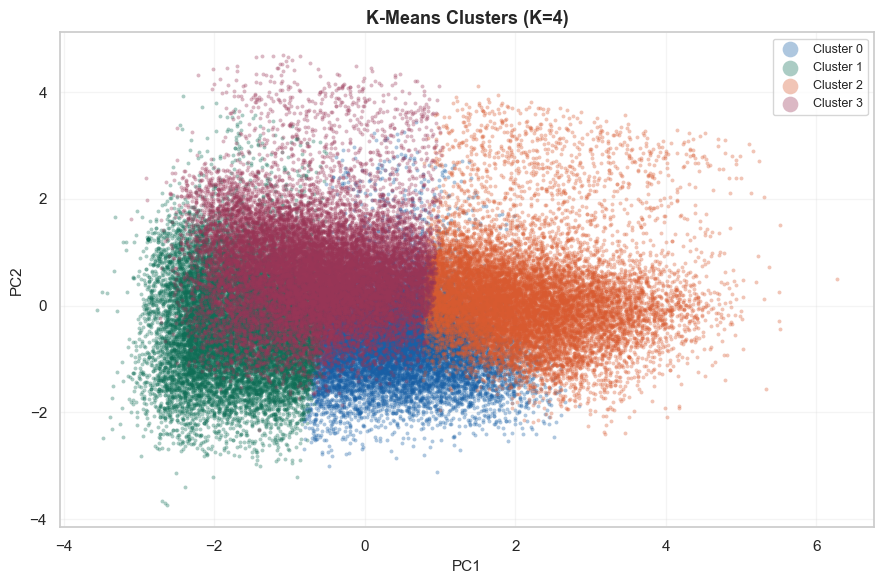

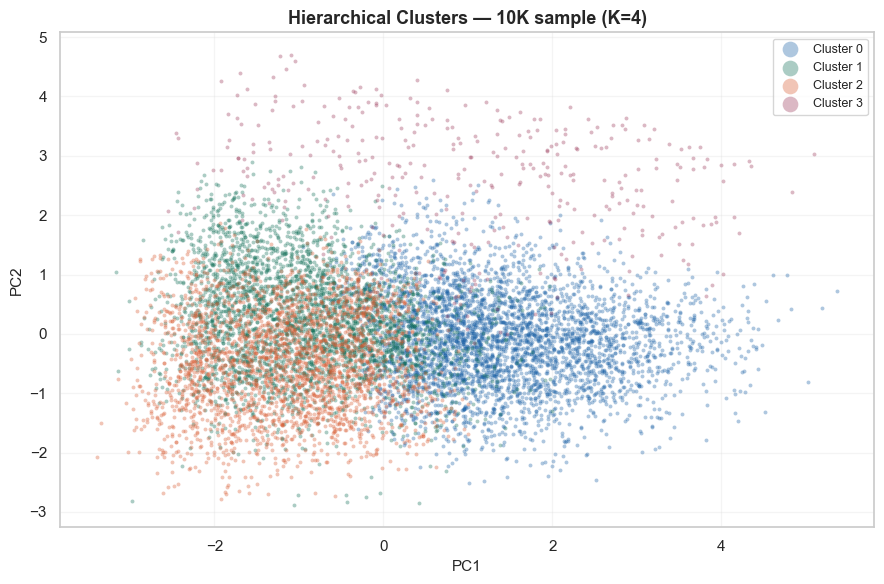

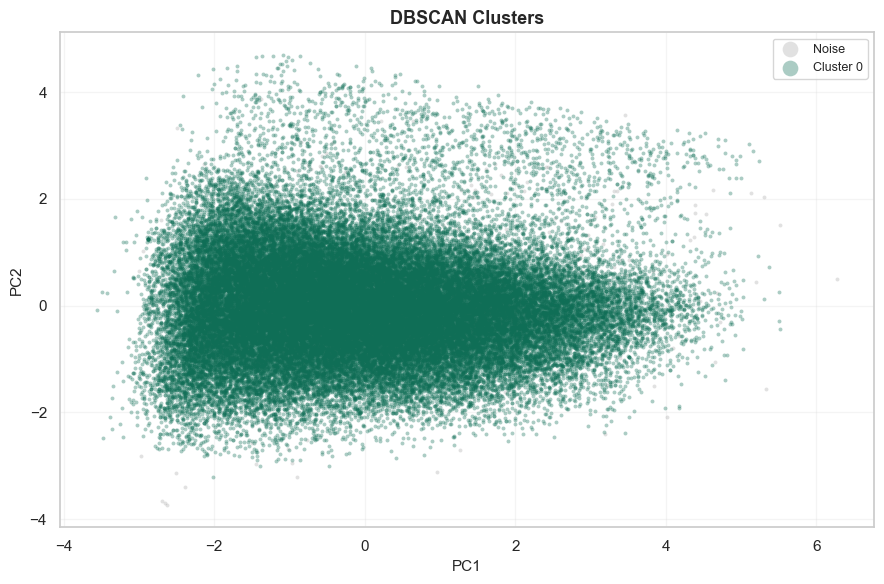

In [27]:
# ── Visualise in PCA space ──

# K-Means — full 62K data, full X_pca
plot_clusters_pca(X_pca, km_labels,
                  title='K-Means Clusters (K=4)',
                  save_name='kmeans_pca')

# Hierarchical — ONLY the 10K sample rows, matching X_pca slice
plot_clusters_pca(X_pca[agg_idx], agg_sample_labels,
                  title='Hierarchical Clusters — 10K sample (K=4)',
                  save_name='hierarchical_pca')

# DBSCAN — full 62K data
plot_clusters_pca(X_pca, db_labels,
                  title='DBSCAN Clusters',
                  save_name='dbscan_pca')

In [28]:
# Compare K-Means vs DBSCAN on full data
# Note: Hierarchical excluded from comparison — different sample size
labels_dict = {
    'K-Means' : km_labels,
    'DBSCAN'  : db_labels
}
comparison_df = compare_all_algorithms(X_scaled.values, labels_dict)
# plot_metrics_comparison(comparison_df)

       Algorithm Comparison — Evaluation Metrics

  K-Means
    Clusters found   : 4
    Noise points     : 0
    Silhouette Score : 0.2045
    Davies-Bouldin   : 1.4962

  DBSCAN
    Clusters found   : 1
    Noise points     : 179
    Silhouette Score : N/A (only 1 cluster found)
    Davies-Bouldin   : N/A (only 1 cluster found)


            Clusters  Noise Points  Silhouette ↑  Davies-Bouldin ↓
Algorithm                                                        
K-Means           4             0        0.2045            1.4962
DBSCAN            1           179           NaN               NaN


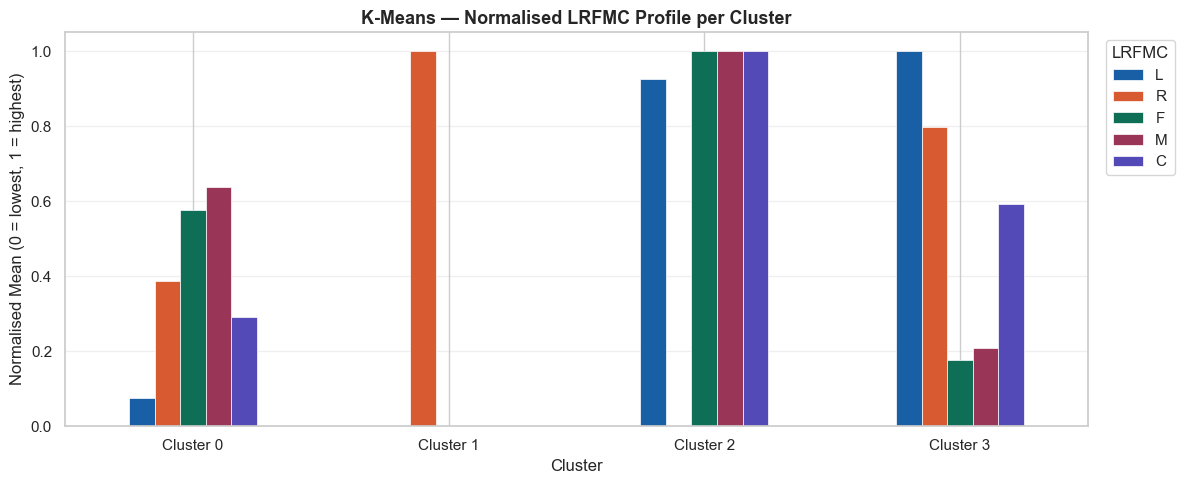


K-Means — Raw Mean LRFMC Values per Cluster:
             L      R      F       M      C
Cluster                                    
0        6.644  3.935  2.471   9.667  0.705
1        6.562  5.514  1.403   8.292  0.678
2        7.559  2.940  3.254  10.444  0.771
3        7.640  4.995  1.731   8.742  0.733


In [29]:
# Profile the K-Means clusters
profile = plot_cluster_profiles(df_lrfmc, km_labels, algo_name='K-Means')
# plot_feature_boxplots(df_lrfmc, km_labels, algo_name='K-Means')

In [30]:
# Print the raw mean values clearly
print("\n── What each cluster looks like ──\n")
df_lrfmc['Cluster'] = km_labels

summary = df_lrfmc.groupby('Cluster').agg(
    Count=('L', 'count'),
    Avg_L=('L', 'mean'),
    Avg_R=('R', 'mean'),
    Avg_F=('F', 'mean'),
    Avg_M=('M', 'mean'),
    Avg_C=('C', 'mean')
).round(3)

summary['Share_%'] = (summary['Count'] / summary['Count'].sum() * 100).round(1)
print(summary.to_string())


── What each cluster looks like ──

         Count  Avg_L  Avg_R  Avg_F   Avg_M  Avg_C  Share_%
Cluster                                                    
0        14657  6.644  3.935  2.471   9.667  0.705     23.3
1        15514  6.562  5.514  1.403   8.292  0.678     24.7
2        14205  7.559  2.940  3.254  10.444  0.771     22.6
3        18560  7.640  4.995  1.731   8.742  0.733     29.5


### L (membership length):
  * Cluster 3 → 7.640  ← HIGHEST  (longest members)
  * Cluster 2 → 7.559  ← HIGH
  * Cluster 0 → 6.644  ← LOW
  * Cluster 1 → 6.562  ← LOWEST   (newest members)

### R (recency — lower = flew more recently):
  * Cluster 1 → 5.514  ← HIGHEST  (haven't flown recently)
  * Cluster 3 → 4.995  ← HIGH     (not recent)
  * Cluster 0 → 3.935  ← LOW      (fairly recent)
  * Cluster 2 → 2.940  ← LOWEST   (flew very recently ✓)

### F (frequency — higher = more flights):
  * Cluster 2 → 3.254  ← HIGHEST  (flies the most)
  * Cluster 0 → 2.471  ← HIGH
  * Cluster 3 → 1.731  ← LOW
  * Cluster 1 → 1.403  ← LOWEST   (flies the least)

### M (monetary/km — higher = more km flown):
  * Cluster 2 → 10.444 ← HIGHEST  (most km)
  * Cluster 0 → 9.667  ← HIGH
  * Cluster 3 → 8.742  ← LOW
  * Cluster 1 → 8.292  ← LOWEST   (least km)

### C (discount — higher = pays more full fare):
  * Cluster 2 → 0.771  ← HIGHEST  (least discount sensitive)
  * Cluster 3 → 0.733  ← MEDIUM
  * Cluster 0 → 0.705  ← MEDIUM
  * Cluster 1 → 0.678  ← LOWEST   (most discount sensitive)

# Naming Each Cluster

### Cluster 2 — 🏆 Champions (22.6%)
* L → High    (long membership)
* R → LOWEST  (flew most recently — still very active)
* F → HIGHEST (flies the most)
* M → HIGHEST (most km flown)
* C → HIGHEST (pays closest to full fare)
> **Who they are:** Long-term members who fly frequently, flew very recently, cover the most distance, and pay close to full fare. These are your most valuable customers — business travelers or frequent long-haul flyers.\
**Business action:** Protect at all costs. Give them priority boarding, lounge access, exclusive tier rewards. If they churn, revenue drops significantly.

### Cluster 0 — ✈️ Loyal Regulars (23.3%)
* L → Low-Medium  (moderate membership length)
* R → Low         (flew fairly recently)
* F → High        (flies often)
* M → High        (good km total)
* C → Medium      (moderate discount sensitivity)
>**Who they are:** Active, regular flyers who haven't been members as long as Cluster 2 but are still highly engaged. Consistent contributors to revenue. Likely regional business travelers.\
**Business action:** Push them toward the next loyalty tier. Milestone rewards — "You're 10 flights away from Gold status." These are your most promotable customers.

### Cluster 3 — ⚠️ At-Risk Customers (29.5% — largest group)
* L → HIGHEST  (been members the longest)
* R → High     (haven't flown recently)
* F → Low      (low flight frequency)
* M → Low      (low km)
* C → Medium   (moderate discount)
>**Who they are:** Long-term members who used to be active but are no longer flying. They have the longest membership history but the recent behavior has dropped off. This is your at-risk churn group.\
**Business action:** Win-back campaign. "We miss you" email with a targeted points bonus or discount on their most-flown route. Identify the top 30% by historical value and invest in re-engagement.

### Cluster 1 — 🎯 Occasional/Leisure Flyers (24.7%)
* L → LOWEST   (newest members)
* R → HIGHEST  (haven't flown in the longest time)
* F → LOWEST   (flies least)
* M → LOWEST   (least km)
* C → LOWEST   (most discount sensitive)
>**Who they are:** Relatively new members who fly infrequently, haven't flown recently, cover short distances, and are very price sensitive. Classic leisure/holiday travelers who only book when there's a deal.\
**Business action:** Seasonal promotions and flash sales. Don't over-invest in loyalty conversion — their price sensitivity makes deep loyalty unlikely. Focus on incremental revenue through targeted offers around holiday seasons.

In [31]:
# Add segment names to the dataframe
segment_map = {
    0: 'Loyal Regulars',
    1: 'Occasional Leisure Flyers',
    2: 'Champions',
    3: 'At-Risk Customers'
}

df_lrfmc['Segment'] = df_lrfmc['Cluster'].map(segment_map)

# Show segment distribution
print("── Final Customer Segments ──\n")
seg_counts = df_lrfmc['Segment'].value_counts()
for seg, count in seg_counts.items():
    pct = count / len(df_lrfmc) * 100
    print(f"  {seg:<28}: {count:>6,} customers ({pct:.1f}%)")

── Final Customer Segments ──

  At-Risk Customers           : 18,560 customers (29.5%)
  Occasional Leisure Flyers   : 15,514 customers (24.7%)
  Loyal Regulars              : 14,657 customers (23.3%)
  Champions                   : 14,205 customers (22.6%)


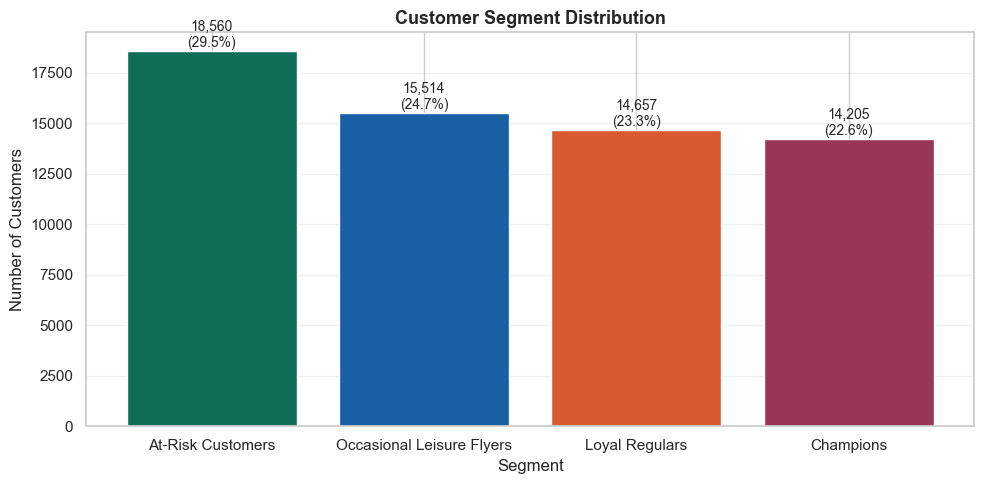

In [32]:
# Visualise segment distribution
import matplotlib.pyplot as plt

colors = ['#0F6E56', '#185FA5', '#D85A30', '#993556']
counts = df_lrfmc['Segment'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(counts.index, counts.values,
              color=colors, edgecolor='white')
ax.set_title('Customer Segment Distribution',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Customers')
ax.set_xlabel('Segment')

for bar, val in zip(bars, counts.values):
    pct = val / len(df_lrfmc) * 100
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 200,
            f'{val:,}\n({pct:.1f}%)',
            ha='center', fontsize=10)

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/reports/segment_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# Save final deliverable
df_lrfmc.to_csv('../data/processed/dataset_with_clusters.csv', index=False)
print("✓ Final dataset saved to outputs/clusters/dataset_with_clusters.csv")
print(f"  Shape: {df_lrfmc.shape}")
print(f"  Columns: {df_lrfmc.columns.tolist()}")

✓ Final dataset saved to outputs/clusters/dataset_with_clusters.csv
  Shape: (62936, 7)
  Columns: ['L', 'R', 'F', 'M', 'C', 'Cluster', 'Segment']


In [34]:
import joblib
joblib.dump(scaler,   '../outputs/models/scaler.pkl')
joblib.dump(km_model, '../outputs/models/kmeans_model.pkl')
joblib.dump(pca,      '../outputs/models/pca.pkl')

['../outputs/models/pca.pkl']

## Key Insights

1. Champions (Cluster 2, 22.6%) are the most valuable segment —
   highest frequency, most recent, most km, least price sensitive.
   Priority: retain at all costs.

2. At-Risk Customers (Cluster 3, 29.5%) are the largest group and
   the most urgent business problem — long-term members who have
   stopped flying. A targeted win-back campaign here has the highest
   potential ROI.

3. Loyal Regulars (Cluster 0, 23.3%) are the growth opportunity —
   active and engaged, one tier upgrade push away from becoming
   Champions.

4. Occasional Flyers (Cluster 1, 24.7%) are price-driven. Deep
   loyalty investment is unlikely to work — seasonal promotions
   and flash sales are more appropriate.

5. DBSCAN found only 1 cluster, confirming that customer behavioral
   data has gradual boundaries, not sharp density gaps. K-Means
   is the right algorithm for this problem.

6. PCA retained 68.9% of variance in 2 components — confirming
   that LRFMC captures real low-dimensional structure in the data.